In [6]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams
rcParams['figure.figsize']=(24,16)
rcParams['font.size']=30
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

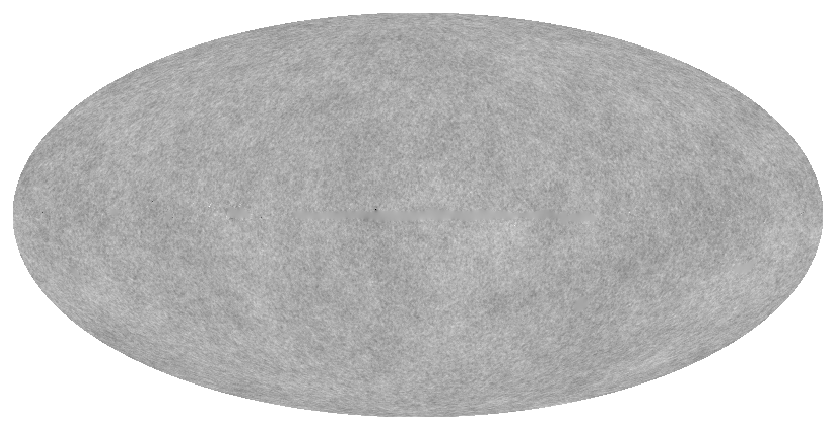

In [7]:
map = hp.read_map('../data/all_data.fits')

hp.mollview(map, title=None, cbar=False, cmap='binary')
plt.savefig('cmb.jpeg', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/pl/vxvp849x7cq56cpszbltdh9r0000gn/T/ipykernel_7437/259139693.py:1: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  map_raw = hp.read_map('../data/all_data.fits', field=0, verbose=False)


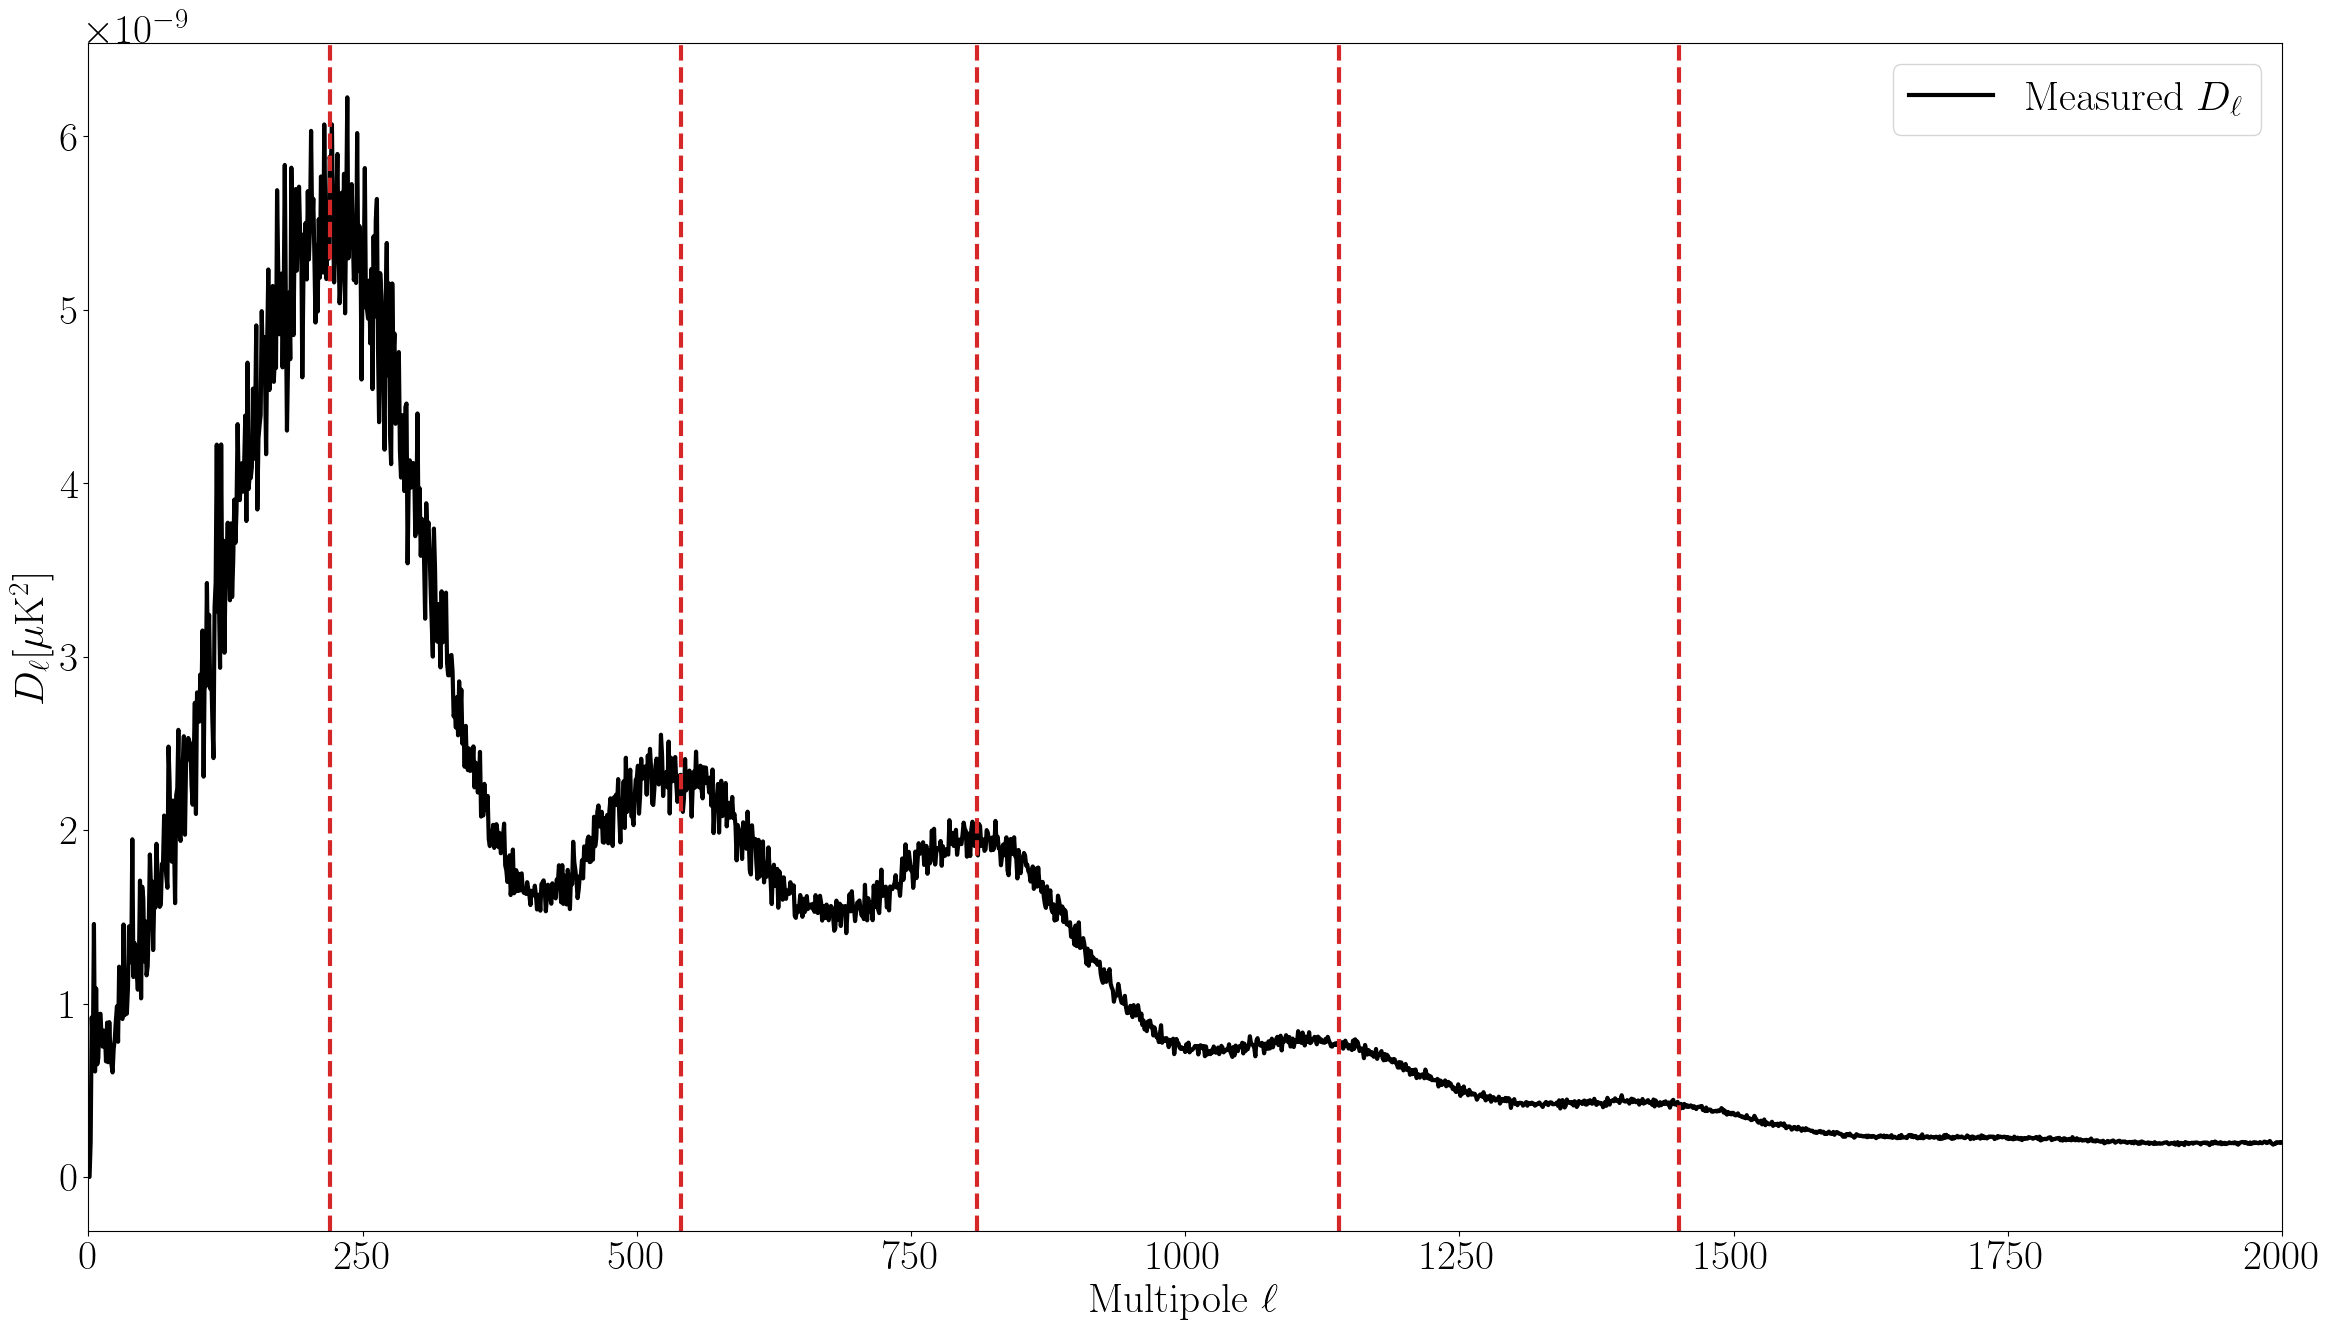

In [11]:
map_raw = hp.read_map('../data/all_data.fits', field=0, verbose=False)
nside = hp.get_nside(map_raw)

map_clean = np.where(map_raw == hp.UNSEEN, 0, map_raw)

cl = hp.anafast(map_clean, lmax=2000)
ell = np.arange(len(cl))

dl = ell*(ell+1)*cl/(2*np.pi)

plt.figure(figsize=(24, 14))
plt.plot(ell, dl, lw=3, label='Measured $D_\\ell$', color='k')

plt.axvline(220, color='tab:red', lw=3, ls='--')
plt.axvline(540, color='tab:red', lw=3, ls='--')
plt.axvline(810, color='tab:red', lw=3, ls='--')
plt.axvline(1140, color='tab:red', lw=3, ls='--')
plt.axvline(1450, color='tab:red', lw=3, ls='--')

plt.xlabel('Multipole $\\ell$')
plt.ylabel('$D_\\ell[\\mu\\rm K^2]$')
# plt.title('CMB Power Spectrum from map')
plt.xlim(0, 2000)
plt.legend()

plt.tight_layout()
plt.savefig('cmb_power_spectrum.jpeg', dpi=300, bbox_inches='tight')
plt.show()